# Titanic Survival Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 90
np.random.seed(42)
print("Style and seed set")

Style and seed set


In [3]:
df = pd.read_csv("titanic.csv")
print("File loaded")

File loaded


In [4]:
print("Rows, Columns:", df.shape)

Rows, Columns: (891, 12)


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
df.sample(5, random_state=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,D17,S
223,224,0,3,"Nenkoff, Mr. Christo",male,NaN,0,0,349234,7.8958,NaN,S
84,85,1,2,"Ilett, Miss. Bertha",female,17.0,0,0,SO/C 14885,10.5000,NaN,S
680,681,0,3,"Peters, Miss. Katie",female,NaN,0,0,330935,8.1375,NaN,Q
535,536,1,2,"Hart, Miss. Eva Miriam",female,7.0,0,2,F.C.C. 13529,26.2500,NaN,S


---
# Phase 3 Understanding the columns

Let's understand what each column means:

| Column | Meaning |
|---|---|
| `PassengerId` | unique ID number |
| `Survived` |  **TARGET** — 0 = died, 1 = survived |
| `Pclass` | ticket class — 1 = First, 2 = Second, 3 = Third |
| `Name` | passenger's full name |
| `Sex` | male / female |
| `Age` | age in years |
| `SibSp` | # of siblings/spouses on board |
| `Parch` | # of parents/children on board |
| `Ticket` | ticket number |
| `Fare` | ticket price (£) |
| `Cabin` | cabin number |
| `Embarked` | port boarded — C = Cherbourg, Q = Queenstown, S = Southampton |

In [8]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [9]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
(df.isnull().sum() / len(df) * 100).round(2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

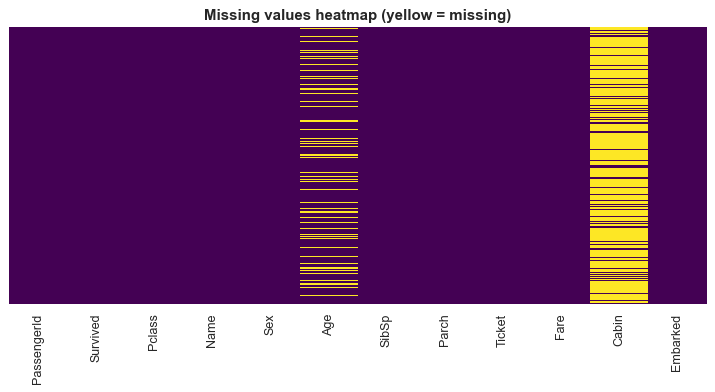

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values heatmap (yellow = missing)", fontweight="bold")
plt.show()

In [16]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [17]:
df["Survived"].value_counts(normalize=True).round(3) * 100

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

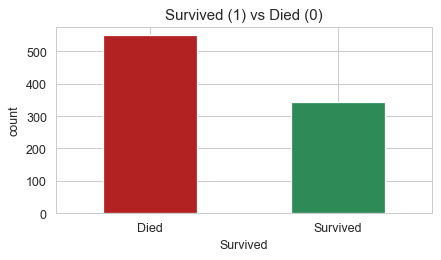

In [18]:
plt.figure(figsize=(5, 3))
df["Survived"].value_counts().plot(kind="bar", color=["firebrick", "seagreen"])
plt.title("Survived (1) vs Died (0)")
plt.xticks([0, 1], ["Died", "Survived"], rotation=0)
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [19]:
df.groupby("Sex")["Survived"].mean().round(3)

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

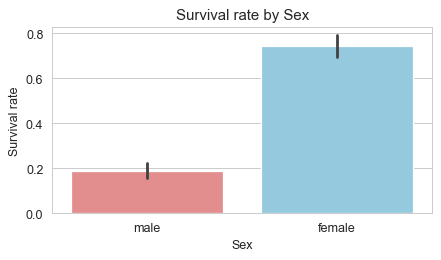

In [20]:
plt.figure(figsize=(5, 3))
sns.barplot(x="Sex", y="Survived", data=df, palette=["lightcoral", "skyblue"])
plt.title("Survival rate by Sex")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.show()

In [21]:
df.groupby("Pclass")["Survived"].mean().round(3)

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

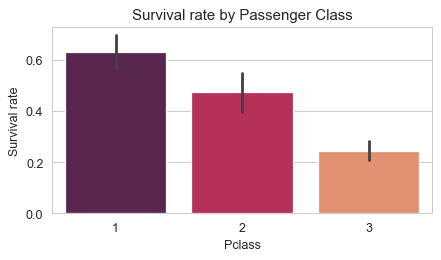

In [22]:
plt.figure(figsize=(5, 3))
sns.barplot(x="Pclass", y="Survived", data=df, palette="rocket")
plt.title("Survival rate by Passenger Class")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.show()

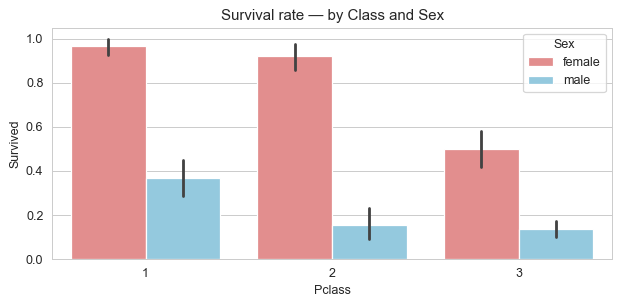

In [23]:
plt.figure(figsize=(7, 3.5))
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df,
            palette={"male": "skyblue", "female": "lightcoral"})
plt.title("Survival rate — by Class and Sex")
plt.tight_layout()
plt.show()

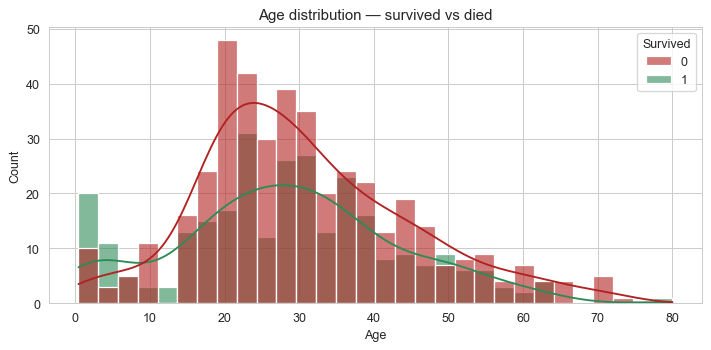

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True,
             palette={0: "firebrick", 1: "seagreen"}, alpha=0.6)
plt.title("Age distribution — survived vs died")
plt.tight_layout()
plt.show()

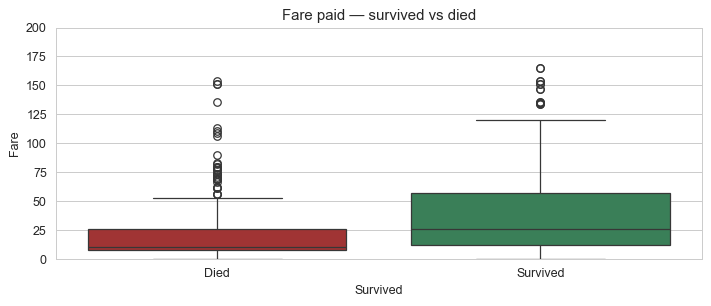

In [25]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x="Survived", y="Fare", data=df, palette=["firebrick", "seagreen"])
plt.title("Fare paid — survived vs died")
plt.xticks([0, 1], ["Died", "Survived"])
plt.ylim(0, 200)
plt.tight_layout()
plt.show()

In [26]:
df.groupby("Embarked")["Survived"].mean().round(3)

Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64

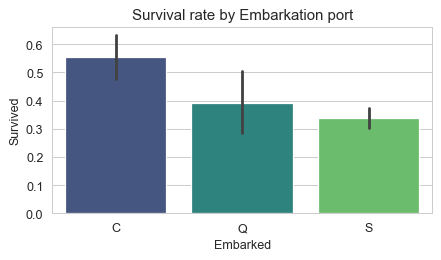

In [27]:
plt.figure(figsize=(5, 3))
sns.barplot(x="Embarked", y="Survived", data=df, palette="viridis", order=["C", "Q", "S"])
plt.title("Survival rate by Embarkation port")
plt.tight_layout()
plt.show()

In [28]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1   # +1 = themselves
df.groupby("FamilySize")["Survived"].mean().round(3)

FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64

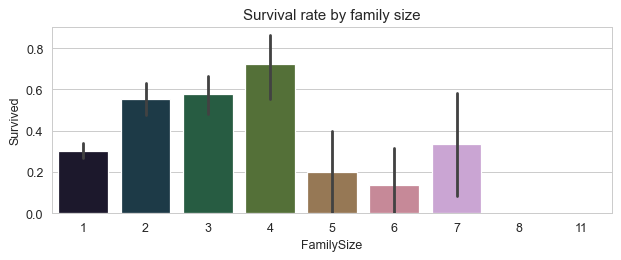

In [29]:
plt.figure(figsize=(7, 3))
sns.barplot(x="FamilySize", y="Survived", data=df, palette="cubehelix")
plt.title("Survival rate by family size")
plt.tight_layout()
plt.show()

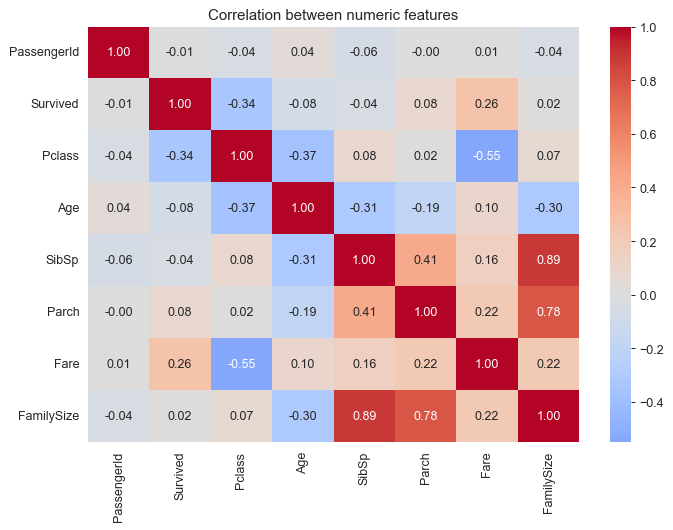

In [30]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

In [31]:
# PassengerId is just an ID, not predictive
# Ticket has too many unique values, hard to use
# Cabin is 77% missing, drop it
# Name has info but we'll handle it separately

df_clean = df.drop(columns=["PassengerId", "Ticket", "Cabin"])
print("New shape:", df_clean.shape)
df_clean.head()

New shape: (891, 10)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1


In [32]:
# Names like "Braund, Mr. Owen Harris" contain a title (Mr, Mrs, Miss, etc.)
# These give us info about social status, sex, age, marital status

df_clean["Title"] = df_clean["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df_clean["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [33]:
# Group rare titles into a single category called "Rare"
common_titles = ["Mr", "Mrs", "Miss", "Master"]
df_clean["Title"] = df_clean["Title"].apply(lambda t: t if t in common_titles else "Rare")
df_clean["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [34]:
# Now we can drop the Name column
df_clean = df_clean.drop(columns=["Name"])
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Title
0,0,3,male,22.0,1,0,7.2500,S,2,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,Mr


In [35]:
# Strategy: fill with median age WITHIN each title group
# (a missing 'Master' is likely a child, a missing 'Mrs' is likely an adult)

df_clean["Age"] = df_clean.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)
print("Missing Age now:", df_clean["Age"].isnull().sum())

Missing Age now: 0


In [36]:
# Only 2 missing — fill with the most common port
most_common_port = df_clean["Embarked"].mode()[0]
print("Most common port:", most_common_port)
df_clean["Embarked"] = df_clean["Embarked"].fillna(most_common_port)
print("Missing Embarked now:", df_clean["Embarked"].isnull().sum())

Most common port: S
Missing Embarked now: 0


In [37]:
df_clean.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
Title         0
dtype: int64

In [38]:
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [ ]:
df_clean["AgeGroup"] = pd.cut(df_clean["Age"],
                               bins=[0, 12, 18, 35, 60, 100],
                               labels=["Child", "Teen", "Adult", "Middle", "Senior"])
df_clean["AgeGroup"].value_counts()

AgeGroup
Adult     530
Middle    196
Child      73
Teen       70
Senior     22
Name: count, dtype: int64

In [40]:
# Survival rate by age group
df_clean.groupby("AgeGroup", observed=True)["Survived"].mean().round(3)

AgeGroup
Child     0.575
Teen      0.429
Adult     0.353
Middle    0.398
Senior    0.227
Name: Survived, dtype: float64

In [41]:
df_clean["FareGroup"] = pd.qcut(df_clean["Fare"], 4,
                                 labels=["Low", "Medium", "High", "VeryHigh"])
df_clean["FareGroup"].value_counts()

FareGroup
Medium      224
Low         223
High        222
VeryHigh    222
Name: count, dtype: int64

In [42]:
df_clean.select_dtypes(include=["object", "category"]).head()

,Sex,Embarked,Title,AgeGroup,FareGroup
0,male,S,Mr,Adult,Low
1,female,C,Mrs,Middle,VeryHigh
2,female,S,Miss,Adult,Medium
3,female,S,Mrs,Adult,VeryHigh
4,male,S,Mr,Adult,Medium


In [43]:
df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})
df_clean["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [44]:
# pd.get_dummies creates one column per category, with 0/1 values
df_encoded = pd.get_dummies(df_clean,
                             columns=["Embarked", "Title", "AgeGroup", "FareGroup"],
                             drop_first=True,
                             dtype=int)
print("New shape:", df_encoded.shape)
df_encoded.head()

New shape: (891, 22)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Middle,AgeGroup_Senior,FareGroup_Medium,FareGroup_High,FareGroup_VeryHigh
0,0,3,0,22.0,1,0,7.2500,2,0,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,1,38.0,1,0,71.2833,2,0,0,...,0,1,0,0,0,1,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,1,1,0,...,0,0,0,0,1,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,2,0,0,...,0,1,0,0,1,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,1,0,...,1,0,0,0,1,0,0,1,0,0


In [45]:
X = df_encoded.drop(columns=["Survived"])
y = df_encoded["Survived"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 21)
y shape: (891,)


In [46]:
X.columns.tolist()

['Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'FamilySize',
 'IsAlone',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare',
 'AgeGroup_Teen',
 'AgeGroup_Adult',
 'AgeGroup_Middle',
 'AgeGroup_Senior',
 'FareGroup_Medium',
 'FareGroup_High',
 'FareGroup_VeryHigh']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training:", X_train.shape, " ", y_train.shape)
print("Testing: ", X_test.shape, " ", y_test.shape)

Training: (712, 21)   (712,)
Testing:  (179, 21)   (179,)


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)         # use train's mean/std on test

print(" Scaled. Mean ≈ 0, Std ≈ 1 on training set:")
print("  mean:", round(X_train_s.mean(), 4))
print("  std: ", round(X_train_s.std(), 4))

 Scaled. Mean ≈ 0, Std ≈ 1 on training set:
  mean: 0.0
  std:  1.0


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression accuracy: {acc_lr:.4f}")

Logistic Regression accuracy: 0.8603


In [50]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN accuracy: {acc_knn:.4f}")

KNN accuracy: 0.8045


In [51]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)                # tree doesn't need scaling
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree accuracy: {acc_dt:.4f}")

Decision Tree accuracy: 0.8268


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)                # also no scaling needed
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {acc_rf:.4f}")

Random Forest accuracy: 0.8045


In [53]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM accuracy: {acc_svm:.4f}")

SVM accuracy: 0.8268


In [54]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting accuracy: {acc_gb:.4f}")

Gradient Boosting accuracy: 0.8324


In [55]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "SVM", "Gradient Boosting"],
    "Accuracy": [acc_lr, acc_knn, acc_dt, acc_rf, acc_svm, acc_gb],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Logistic Regression,0.860335
1,Gradient Boosting,0.832402
2,SVM,0.826816
3,Decision Tree,0.826816
4,KNN,0.804469
5,Random Forest,0.804469


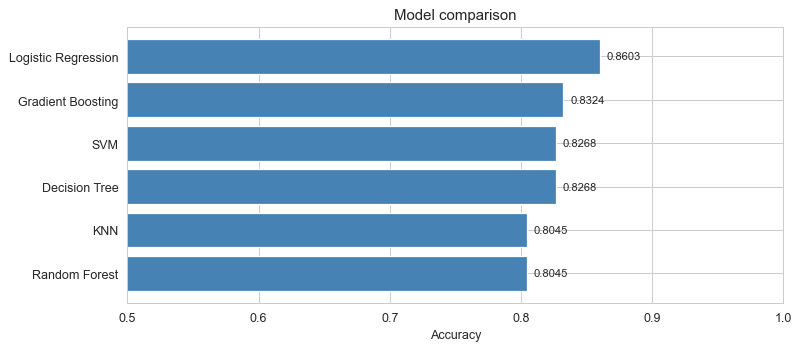

In [56]:
plt.figure(figsize=(9, 4))
bars = plt.barh(results["Model"], results["Accuracy"], color="steelblue")
plt.xlim(0.5, 1.0)
plt.xlabel("Accuracy")
plt.title("Model comparison")
for bar, acc in zip(bars, results["Accuracy"]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{acc:.4f}", va="center", fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [57]:
all_models = {
    "Logistic Regression": (lr, y_pred_lr),
    "KNN": (knn, y_pred_knn),
    "Decision Tree": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
    "SVM": (svm, y_pred_svm),
    "Gradient Boosting": (gb, y_pred_gb),
}
best_name = results.iloc[0]["Model"]
best_model, best_pred = all_models[best_name]
print(f" Best model: {best_name}")

 Best model: Logistic Regression


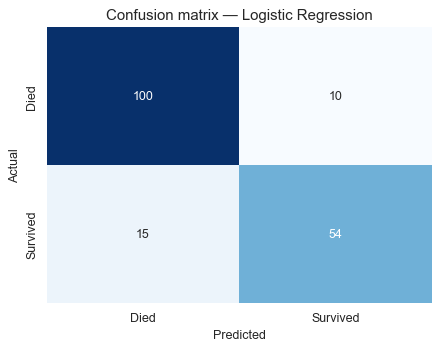

  Correctly predicted Died:     100
  Wrongly predicted Survived:   10
  Wrongly predicted Died:       15
  Correctly predicted Survived: 54


In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"], cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  Correctly predicted Died:     {tn}")
print(f"  Wrongly predicted Survived:   {fp}")
print(f"  Wrongly predicted Died:       {fn}")
print(f"  Correctly predicted Survived: {tp}")

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred,
                            target_names=["Died", "Survived"],
                            digits=4))

              precision    recall  f1-score   support

        Died     0.8696    0.9091    0.8889       110
    Survived     0.8438    0.7826    0.8120        69

    accuracy                         0.8603       179
   macro avg     0.8567    0.8458    0.8505       179
weighted avg     0.8596    0.8603    0.8593       179



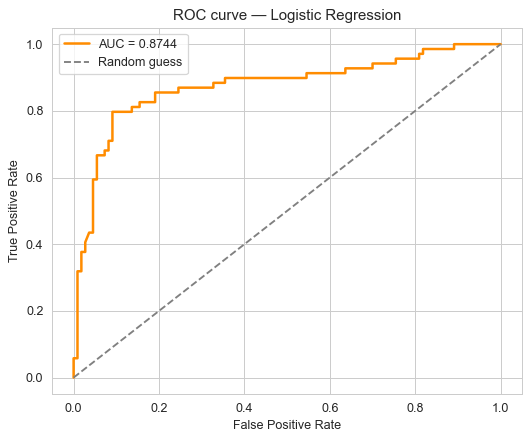

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

# Tree-based models accept the unscaled X; others need the scaled version.
tree_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]
X_for_proba = X_test if best_name in tree_models else X_test_s

y_proba = best_model.predict_proba(X_for_proba)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

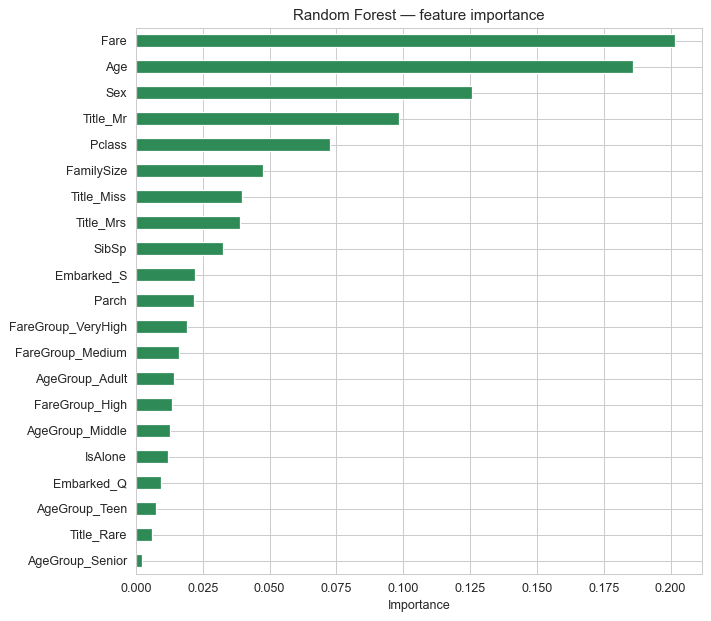

In [61]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 7))
importances.plot(kind="barh", color="seagreen")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [62]:
importances.tail(5).iloc[::-1]

Fare        0.201673
Age         0.185839
Sex         0.125883
Title_Mr    0.098374
Pclass      0.072434
dtype: float64

In [63]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("5-fold CV accuracies:", cv_scores.round(4))
print(f"Mean: {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})")

5-fold CV accuracies: [0.7989 0.7865 0.8427 0.764  0.809 ]
Mean: 0.8002  (±0.0260)


In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
acc_best = accuracy_score(y_test, best_rf.predict(X_test))
print(f"Test accuracy with best params: {acc_best:.4f}")

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.8273
Test accuracy with best params: 0.8212


In [65]:
# Imagine a new passenger: 1st class, female, 28 years old, paid £80, embarked at C (Cherbourg)
# We must build a row with the SAME columns as X (the training features).

# Easiest safe approach: start with all zeros, then set the values we know.
new_passenger = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

new_passenger["Pclass"] = 1
new_passenger["Sex"] = 1                # 1 = female
new_passenger["Age"] = 28
new_passenger["SibSp"] = 0
new_passenger["Parch"] = 0
new_passenger["Fare"] = 80
new_passenger["FamilySize"] = 1
new_passenger["IsAlone"] = 1
# Embarked: C is the dropped baseline (drop_first=True), so leave Q=0 and S=0
# Title: Master is dropped baseline; we want Mrs
new_passenger["Title_Mrs"] = 1
# AgeGroup: Child is dropped baseline; we want Adult
new_passenger["AgeGroup_Adult"] = 1
# FareGroup: Low is dropped baseline; we want VeryHigh
new_passenger["FareGroup_VeryHigh"] = 1

prediction = best_rf.predict(new_passenger)[0]
probability = best_rf.predict_proba(new_passenger)[0]

print("Predicted:", "Survived " if prediction == 1 else "Died ")
print(f"Confidence: died = {probability[0]:.2%}, survived = {probability[1]:.2%}")

Predicted: Survived 
Confidence: died = 5.52%, survived = 94.48%
